
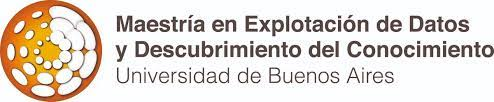

##      **_Data mining en Ciencia y Tecnología_**

Clustering de Imágenes

In [ ]:
from keras.applications.vgg16 import VGG16, preprocess_input
from keras.models import Model
from keras.layers import Input
from keras.utils import load_img, img_to_array

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import os
import numpy as np
import matplotlib.pyplot as plt
from random import randint
import pandas as pd

### Extracción de features de imágenes con la red neuronal VGG16

Definimos un modelo VGG16 utilizando la arquitectura provista por Keras.

Esta trae por defecto los pesos entrenados con ImageNet (ver https://keras.io/api/applications/vgg/).

Luego vamos a redefinir la arquitectura utilizando hasta la anteúltima capa.
Existen diversas formas de hacer esto pero una sencilla en este caso es utilizar un Model genérico y pasarle el input y output del modelo anterior.

Podemos tomar cualquier punto del proceso como output accediendo a la lista de layers y devolviendo la propiedad "output" de esa capa.




In [ ]:
input_tensor = Input(shape=(224, 224, 3)) # Detalle: redefinimos el input tensor para evitar warnings al predecir

model = VGG16(input_tensor=input_tensor)
model = Model(inputs = input_tensor, outputs = model.layers[-2].output) # Salida de la anteúltima capa, antes de la clasificación

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Si observamos que pasamos como output, se trata de un tensor de Keras.
Estos objetos guardan la referencia al tensor anterior, lo que permite a la librería reconstruir el grafo computacional del modelo completo.

In [ ]:
model.layers[-1].output # Accedemos a la última en este caso porque ya recortamos el VGG original)

<KerasTensor shape=(None, 4096), dtype=float32, sparse=False, name=keras_tensor_21>

Observamos como queda el modelo, sin la última capa de 1000 salidas.

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

OBSERVACIÓN: La visión clásica es que las capas fc1 y fc2 (fc = "fully connected") son parte de la cabeza clasificadora. Sin embargo, en muchos estudios de transferencia de aprendizaje se incluye toda la red hasta la capa fc2 (inclusive) como extractor de atributos, ya que contiene una representación muy rica y semántica de las imagenes. En esta implementación tomaremos dicho camino

Definamos funciones útiles

In [ ]:
def preprocess_and_extract(file_list, model):
    images = []
    for file in file_list:
        img = load_img(file, target_size=(224, 224))
        img = img_to_array(img)
        images.append(img)

    # Convertir a array y preprocesar todo junto
    images = np.array(images)
    images = preprocess_input(images)

    # Predecir todas las imágenes en batch
    features = model.predict(images, batch_size=32, verbose=1)
    return np.array(file_list), features

def view_cluster(gps, cluster):
    plt.figure(figsize=(25, 25))
    files = gps
    # Máximo 10 para visualizar
    if len(files) > 10:
        files = files[:10]
    for index, file in enumerate(files):
        plt.subplot(1, 10, index + 1)
        img = load_img(file)
        img = img_to_array(img).astype('uint8')
        plt.imshow(img)
        plt.title(f'Cluster n: {cluster}')
        plt.axis('off')
    plt.show()

Probemos VGG16 aplicándolo al dataset de flores

In [ ]:
!wget -q --show-progress --no-clobber -O kaggle_flower_images.zip "https://www.dropbox.com/scl/fi/mxv5o39ekf6bgshz0g5jf/kaggle_flower_images.zip?rlkey=90gi41kzonieowglmbw75yop3&st=ynk3dv7h&dl=1"
!unzip -o -q kaggle_flower_images.zip

kaggle_flower_image 100%[===================>]   9.48M  --.-KB/s    in 0.06s   


In [ ]:
image_path = "kaggle_flower_images"
path = sorted([os.path.join(image_path, file)
for file in os.listdir(image_path )
if file.endswith('.png')])

print(len(path))
print(path[0])

210
kaggle_flower_images/0001.png


Ahora vamos a aplicar el modelo y extraer las features.

Aclaración: este paso tarda unos 2 minutos en CPU, pero se acelera considerablemente utilizando una GPU. Pueden probar activarla en el entorno de Colab si quieren, aunque no es necesaria para este caso. *No olivden desconectarse cuando terminen para no gastar todos sus créditos gratuitos!*

In [ ]:
names, feat = preprocess_and_extract(path, model)

7/7 ━━━━━━━━━━━━━━━━━━━━ 130s 18s/step


In [ ]:
# Veamos el tamaño de los features de la primera imagen
print('El tamaño de la imagen es ', np.array(load_img(path[0])).shape)
print('El tamaño de la imagen dada como input a VGG16 es ', np.array(load_img(path[0],target_size=(224,224))).shape)
print('El tamaño del array de features de la imagen inferido por VGG16 es ', feat[0].shape)

El tamaño de la imagen es  (128, 128, 3)
El tamaño de la imagen dada como input a VGG16 es  (224, 224, 3)
El tamaño del array de features de la imagen inferido por VGG16 es  (4096,)


Tomemos las etiquetas de las fotos

In [ ]:
## get the unique labels (from the flower_labels.csv)
df = pd.read_csv(image_path+'/flower_labels.csv')
label = df['label'].tolist()
unique_labels = list(set(label))
print(unique_labels)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [ ]:
label[:20]

[0, 0, 2, 0, 0, 1, 6, 0, 0, 0, 0, 0, 0, 7, 7, 1, 0, 0, 6, 0]

Probemos reducir incluso más la dimensionalidad de los features obtenidos via PCA

In [ ]:
# reduce the amount of dimensions in the feature vector
pca = PCA(n_components=100, random_state=22)
pca.fit(feat)
x = pca.transform(feat)

In [ ]:
print(f"Components before PCA: {feat.shape[1]}")
print(f"Components after PCA: {pca.n_components}")

Components before PCA: 4096
Components after PCA: 100


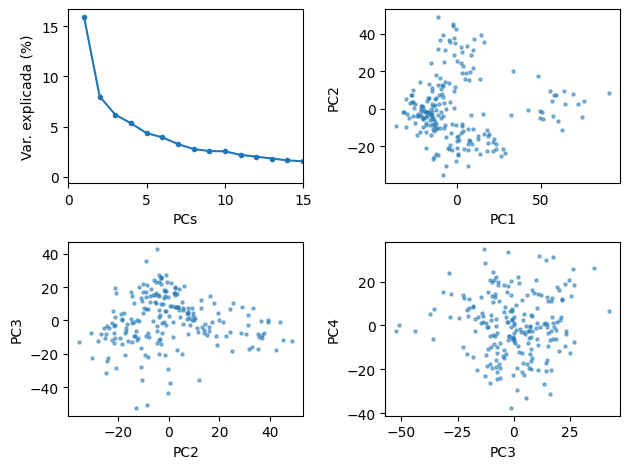

In [ ]:
fig, axs = plt.subplots(2,2)
axs[0,0].plot(np.linspace(1,pca.n_components,pca.n_components),100*pca.explained_variance_ / sum(pca.explained_variance_),'.-')
axs[0,0].set_xlim([0,15])
axs[0,0].set_xlabel('PCs')
axs[0,0].set_ylabel('Var. explicada (%)')

axs[0,1].scatter(x[:,0],x[:,1],s=5, alpha=0.5)
axs[0,1].set_xlabel('PC1')
axs[0,1].set_ylabel('PC2')
axs[1,0].scatter(x[:,1],x[:,2],s=5, alpha=0.5)
axs[1,0].set_xlabel('PC2')
axs[1,0].set_ylabel('PC3')
axs[1,1].scatter(x[:,2],x[:,3],s=5, alpha=0.5)
axs[1,1].set_xlabel('PC3')
axs[1,1].set_ylabel('PC4')

plt.tight_layout()
plt.show()

### Clustering con K-Means

In [ ]:
# kmeans = KMeans(n_clusters=len(unique_labels), n_init='auto') # Si queremos usar la cantidad de labels originales
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(x)

KMeans(n_clusters=3)

In [ ]:
# holds the cluster id and the images { id: [images] }
groups = {}
for file, cluster in zip(names,kmeans.labels_):
    if cluster not in groups.keys():
        groups[cluster] = []
        groups[cluster].append(file)
    else:
        groups[cluster].append(file)


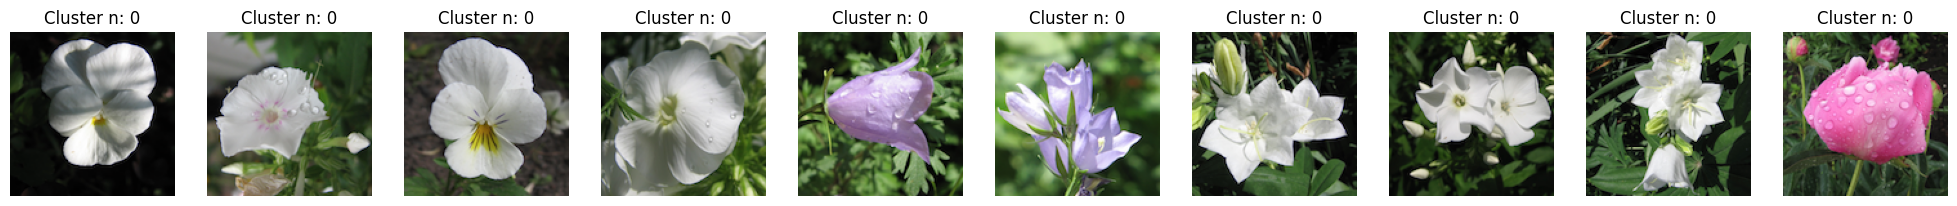

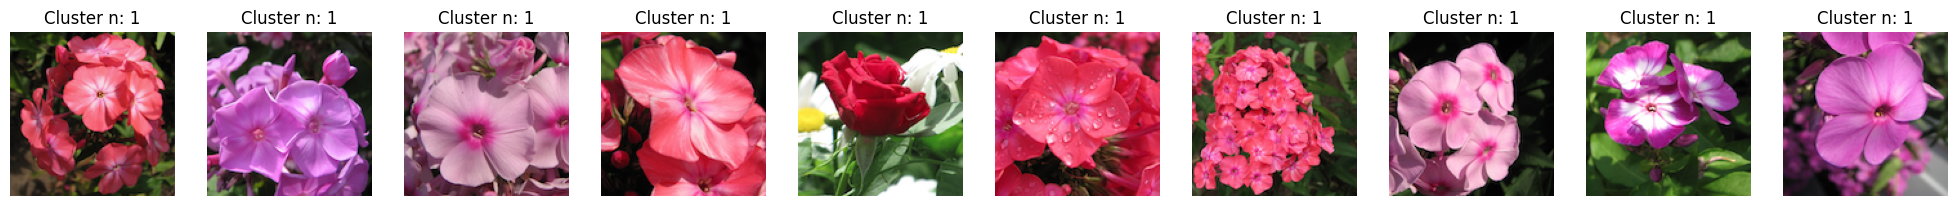

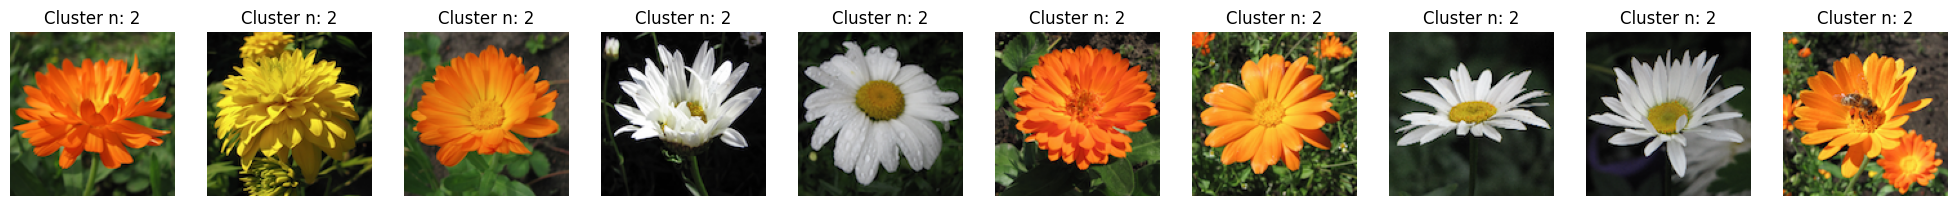

In [ ]:
for n in range(len(groups)):
  view_cluster(groups[n],n)

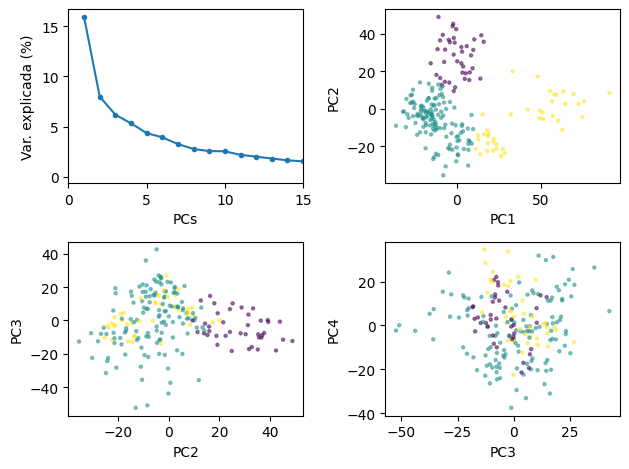

In [ ]:
# VEAMOS LOS CLUSTERS INFERIDOS EN EL ESPACIO DE PCA
fig, axs = plt.subplots(2,2)
axs[0,0].plot(np.linspace(1,pca.n_components,pca.n_components),100*pca.explained_variance_ / sum(pca.explained_variance_),'.-')
axs[0,0].set_xlim([0,15])
axs[0,0].set_xlabel('PCs')
axs[0,0].set_ylabel('Var. explicada (%)')

axs[0,1].scatter(x[:,0],x[:,1],s=5,c=kmeans.labels_, alpha=0.5)
axs[0,1].set_xlabel('PC1')
axs[0,1].set_ylabel('PC2')
axs[1,0].scatter(x[:,1],x[:,2],s=5,c=kmeans.labels_, alpha=0.5)
axs[1,0].set_xlabel('PC2')
axs[1,0].set_ylabel('PC3')
axs[1,1].scatter(x[:,2],x[:,3],s=5,c=kmeans.labels_, alpha=0.5)
axs[1,1].set_xlabel('PC3')
axs[1,1].set_ylabel('PC4')

plt.tight_layout()
plt.show()

In [ ]:
# Graficamos las primeras 3 componentes en un gráfico 3d interactivo
import plotly.graph_objects as go

fig = go.Figure(data=[go.Scatter3d(
    x=x[:,0],
    y=x[:,1],
    z=x[:,2],
    mode='markers',
    marker=dict(
        size=5,
        color=kmeans.labels_,
        colorscale='Viridis',
        opacity=0.8
    )
)])

fig.update_layout(scene=dict(
    xaxis_title='PC1',
    yaxis_title='PC2',
    zaxis_title='PC3'
))

fig.show()

### Algunos ejercicios posibles...

Probar calcular SSE

Probar calcular silhuete

Probar calcular validacion externa contra las etiquetas (matriz de confusión)

In [ ]:
# ETIQUETAS INFERIDAS POR k-means
kmeans.labels_[:20]

array([1, 1, 2, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 2, 1, 1, 1, 0, 0],
      dtype=int32)

In [ ]:
# ETIQUETAS REALES
label[:20]

[0, 0, 2, 0, 0, 1, 6, 0, 0, 0, 0, 0, 0, 7, 7, 1, 0, 0, 6, 0]

In [ ]:
ct = pd.crosstab(label, kmeans.labels_)
ct.index.name = 'Labels_orig'
ct.columns.name = 'Labels_clust'
ct

Labels_clust,0,1,2
Labels_orig,,,
0,5,16,0
1,0,20,0
2,0,3,16
3,1,21,0
4,0,0,21
5,22,2,1
6,5,18,0
7,0,12,3
8,3,23,0
